In [1]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
from sklearn import metrics
import pandas as pd

#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

In [101]:
data = pd.read_csv('housing.csv', header=0)
data = data.drop(columns='ocean_proximity')#Not as interesting for our story.

In [102]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [84]:
X = data.loc[:,'longitude':'median_income']
y = data['median_house_value']
#X = X.values

We want to predict median house value (for this census block) from the other values.

In [85]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

Let's predict using boosting

In [30]:
import xgboost as xgb
from xgboost import XGBRegressor

In [87]:
#xgboost uses its own matrix format (in all languages).
#we don't need this for the first sklearn style interface, but we do for the second
#This can also be done directly from a text file with xgb.DMatrix
train_dm = xgb.DMatrix(X_train.values, y_train, feature_names=data.columns[0:8])
test_dm = xgb.DMatrix(X_test.values, y_test, feature_names=data.columns[0:8])

In [103]:
XGBRegressor?

In [104]:
#Now we can train
boost_fit = XGBRegressor(max_depth=3, learning_rate=0.1, n_estimators=100,
                        subsample=1, random_state=1, gamma=0).fit(X_train, y_train)

In [105]:
predictions = boost_fit.predict(X_test)

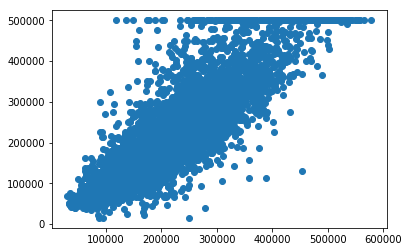

In [106]:
plt.scatter(predictions, y_test)

In [107]:
metrics.mean_absolute_error(y_test, predictions)

38197.18410525543

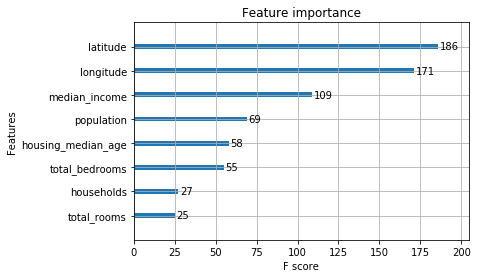

In [92]:
xgb.plot_importance(boost_fit)

In [75]:
from pdpbox import pdp


In [99]:
pdpobj = pdp.pdp_interact(model=boost_fit, dataset=data, num_grid_points=[30,30], model_features= data.columns[0:8], features=['longitude','latitude'])


TypeError: clabel() got an unexpected keyword argument 'contour_label_fontsize'

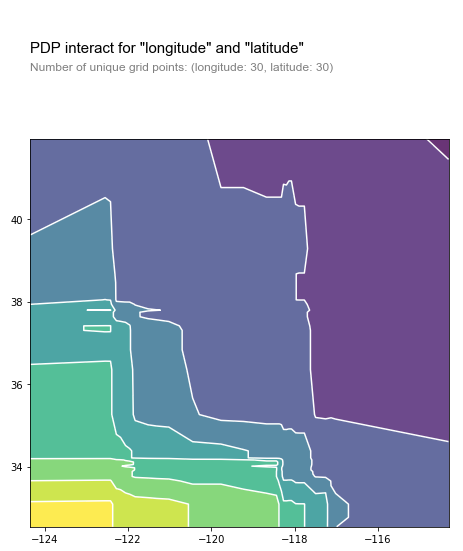

In [100]:
pdp.pdp_interact_plot(pdpobj, feature_names=data.columns[0:8])

that error above looks like something buggy?  But the plot still works...